# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



LODING FILES...

In [1]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# A | Socialdemokratiet | Social Democrats | Centre-left |
# | V | Venstre | Danish Liberal Party | Centre-right |
# | M | Moderaterne | Moderates | Centre-right |
# | F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
# | D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
# | I | Liberal Alliance | Liberal Alliance | Right-wing |
# | C | Konservative | Conservative People's Party | Right-wing |
# | Æ | Enhedslisten | Red-Green Alliance | Far-left |
# | B | Radikale Venstre | Social Liberal Party | Centre-left |
# | D | Nye Borgerlige | New Right | Far-right |
# | Z | Alternativet | The Alternative | Centre-left |
# | O | Dansk Folkeparti | Danish People's Party | Far-right |
# | G | Frie Grønne | Free Greens | Centre-left |
# | K | Kristendemokraterne | Christian Democrats | Centre-right |
# party_letter_mapping = {
#     "Socialdemokratiet": "A",
#     "Venstre": "V",
#     "Moderaterne": "M",
#     "Socialistisk Folkeparti": "F",
#     "Danmarksdemokraterne": "D",
#     "Liberal Alliance": "I",
#     "Konservative": "C",
#     "Enhedslisten": "Æ",
#     "Radikale Venstre": "B",
#     "Nye Borgerlige": "D",
#     "Alternativet": "Z",
#     "Dansk Folkeparti": "O",
#     "Frie Grønne": "G",
#     "Kristendemokraterne": "K"
# }
# NOTE: Party_letter_mapping doesnt really work since the latter D is used twice.


alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')

print(alldata.shape)
display(alldata.head())

(867, 53)


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


### TASK 1 ###
Age of the candidates grouped by parties.


<AxesSubplot: title={'center': 'alder'}, xlabel='parti'>

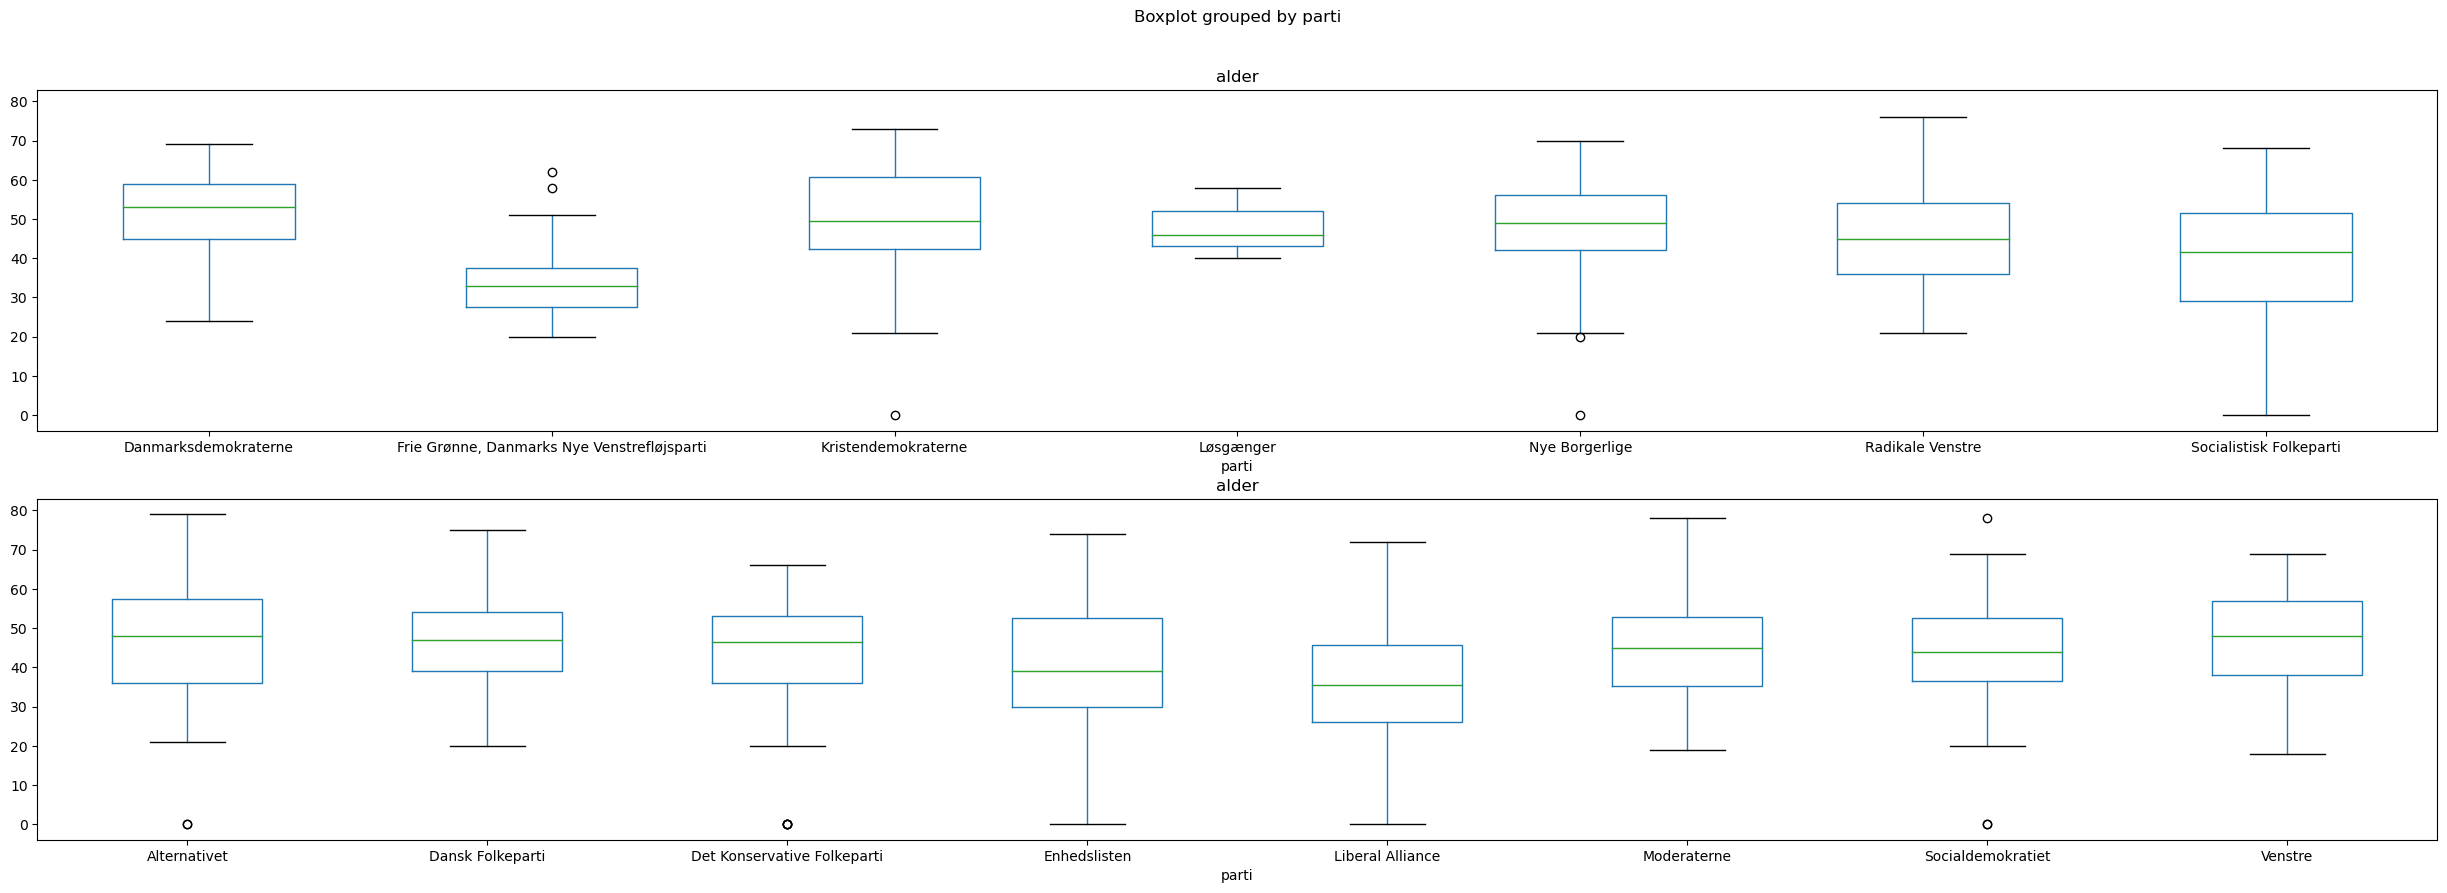

In [3]:
parties = alldata['parti'].unique()

fig, (ax1,ax2) = plt.subplots(nrows=2, ncols=1, figsize=(30,10), sharey=True,)

alldata.loc[alldata['parti'].isin(parties[1::2])].boxplot(ax=ax1, column='alder', by='parti', figsize=(30,10), grid=False)
alldata.loc[alldata['parti'].isin(parties[0::2])].boxplot(ax=ax2, column='alder', by='parti', figsize=(30,10), grid=False)


### TASK 2 ###
An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.

In [4]:
answers = alldata.drop(['alder', 'navn', 'storkreds'], axis=1)
confidences = ((answers == 2) | (answers == -2)).sum(axis=1).sort_values(ascending=False)
display(alldata.loc[confidences.head().index, ['navn', 'parti', 'storkreds']].assign(confidence_score=confidences.head(), confidence_ratio=confidences.head() / answers.shape[1]))


,navn,parti,storkreds,confidence_score,confidence_ratio
505,Sarah Nørris,Enhedslisten,Sydjyllands Storkreds,49,0.98
88,Søren Vanting,Det Konservative Folkeparti,Østjyllands Storkreds,49,0.98
559,Kim Andkjær Doberck,Nye Borgerlige,Sydjyllands Storkreds,44,0.88
152,Rashid Ali,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Københavns Storkreds,43,0.86
44,Mohamed Abdikarim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Østjyllands Storkreds,43,0.86


### TASK 3 ###
Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.

Alternativet | Average standard deviation of all questions: 0.91
Danmarksdemokraterne | Average standard deviation of all questions: 0.61
Dansk Folkeparti | Average standard deviation of all questions: 0.89
Det Konservative Folkeparti | Average standard deviation of all questions: 0.89
Enhedslisten | Average standard deviation of all questions: 0.68
Frie Grønne, Danmarks Nye Venstrefløjsparti | Average standard deviation of all questions: 0.67
Kristendemokraterne | Average standard deviation of all questions: 1.03
Liberal Alliance | Average standard deviation of all questions: 0.73
Løsgænger | Average standard deviation of all questions: 1.45
Moderaterne | Average standard deviation of all questions: 0.89
Nye Borgerlige | Average standard deviation of all questions: 0.56
Radikale Venstre | Average standard deviation of all questions: 0.86
Socialdemokratiet | Average standard deviation of all questions: 0.83
Socialistisk Folkeparti | Average standard deviation of all questions: 0.66
Ven

<AxesSubplot: xlabel='parti'>

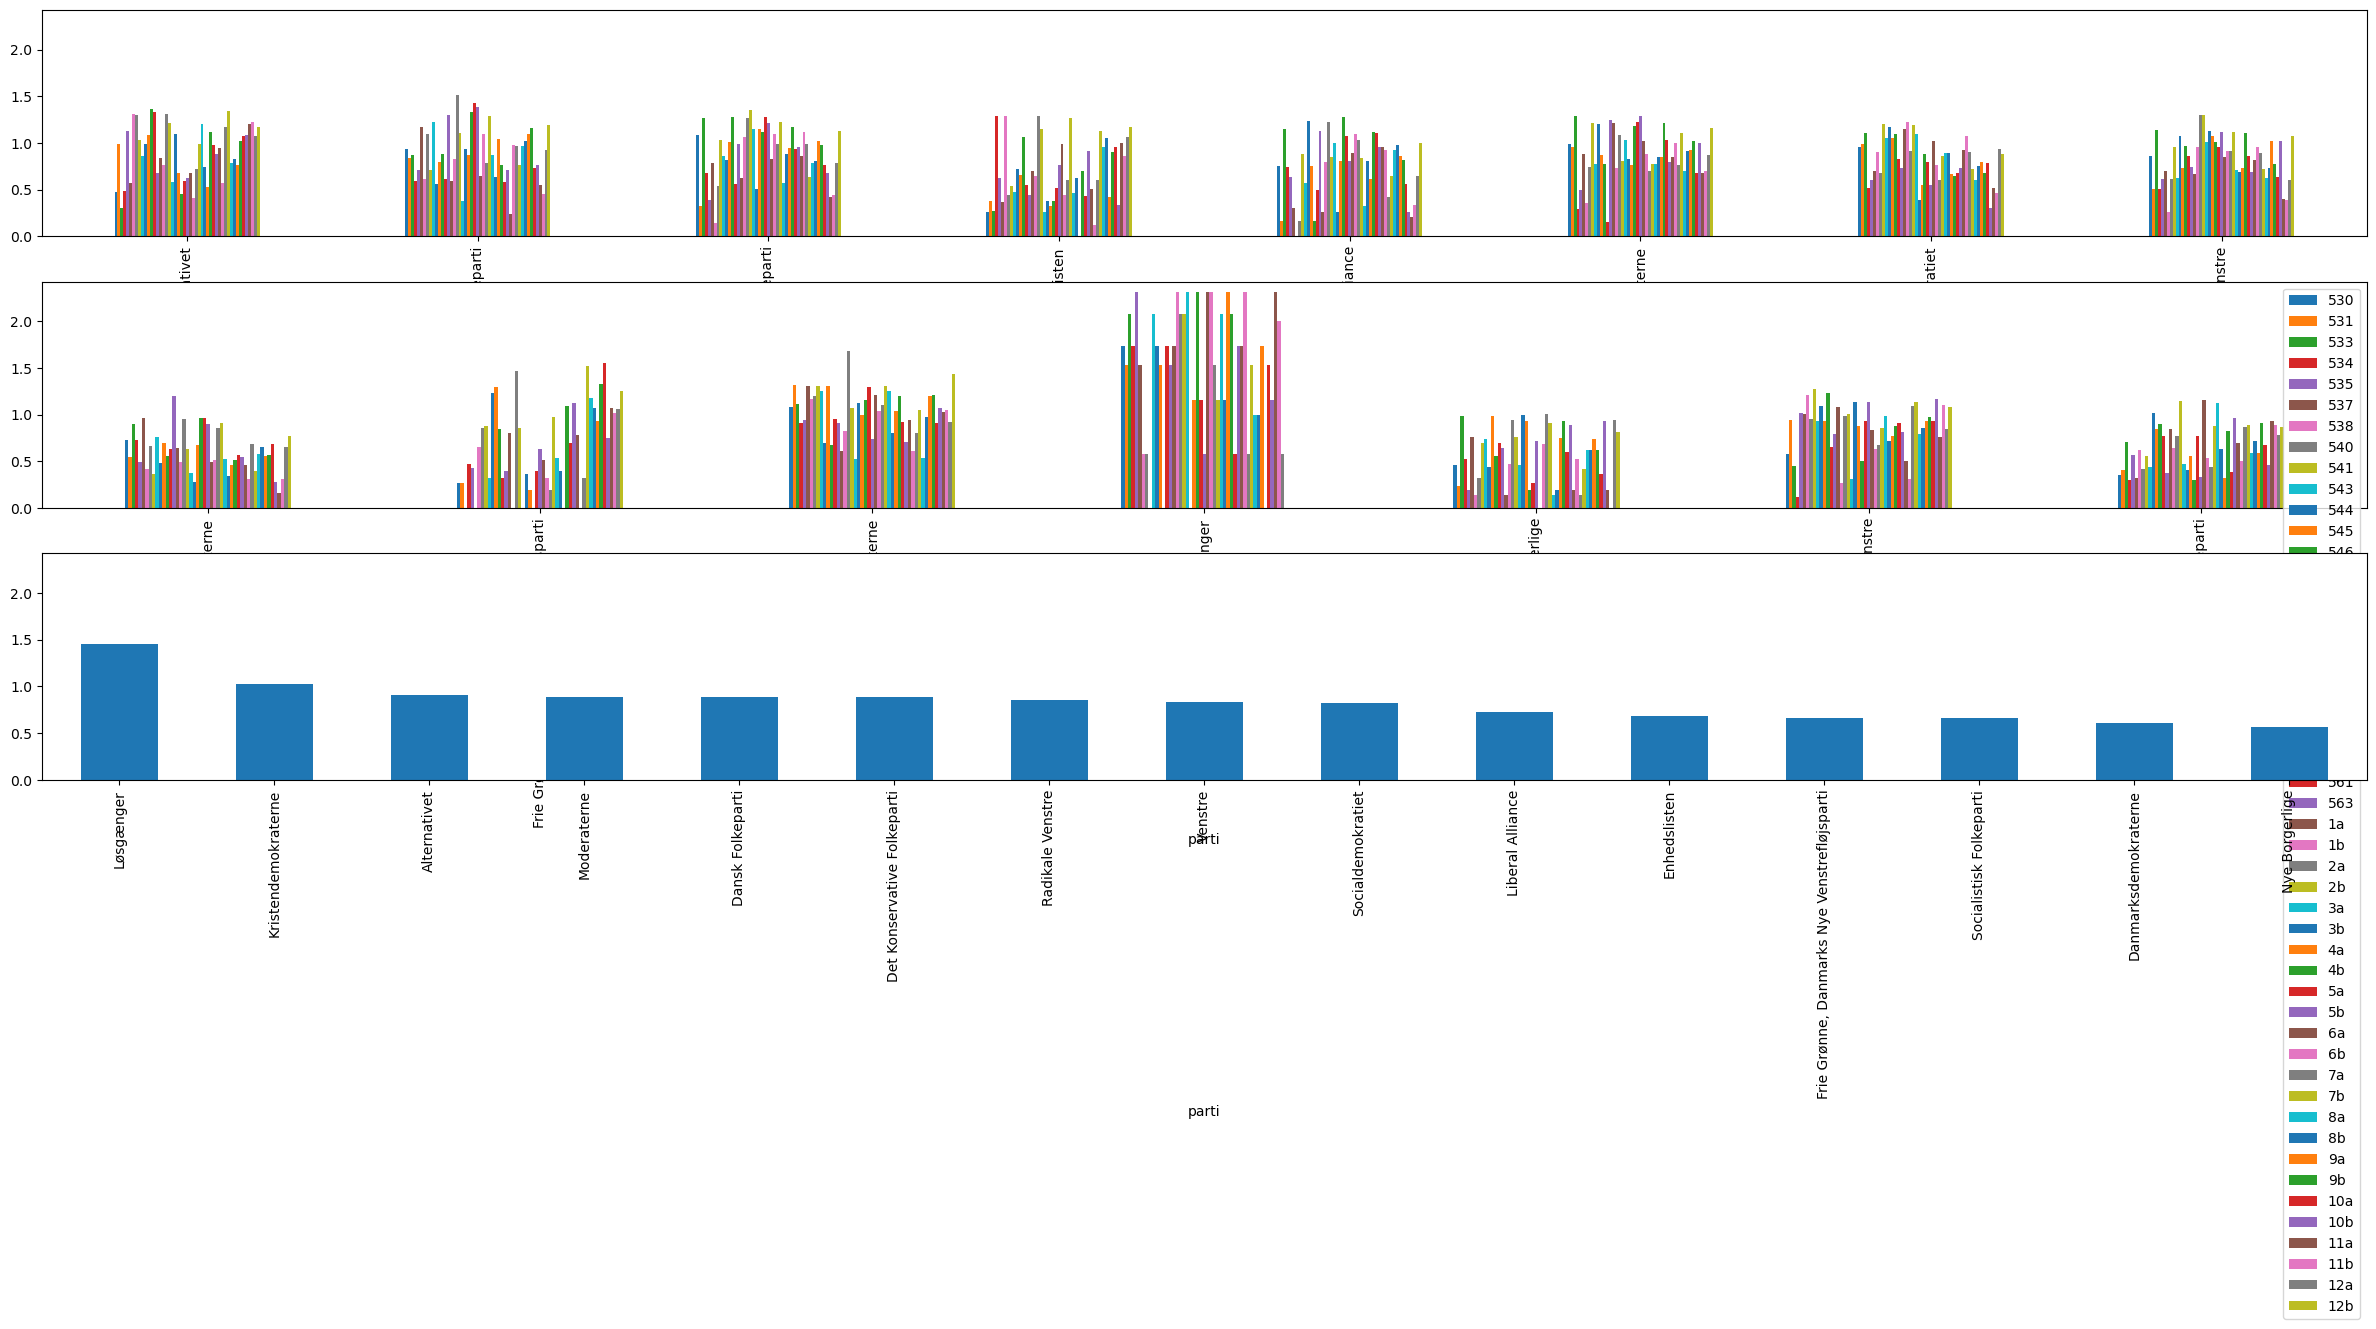

In [8]:
parties = alldata['parti'].unique()


fig, (ax3, ax4, ax5) = plt.subplots(nrows=3, ncols=1, figsize=(30,10), sharey=True)

alldata.loc[alldata['parti'].isin(parties[1::2])].drop(columns=['alder', 'navn', 'storkreds']).groupby('parti').std().plot(ax=ax4, kind='bar', figsize=(30,10), grid=False,legend=True)
alldata.loc[alldata['parti'].isin(parties[0::2])].drop(columns=['alder', 'navn', 'storkreds']).groupby('parti').std().plot(ax=ax3, kind='bar', figsize=(30,10), grid=False, legend=False)

def printout_func(row: pd.Series):
    print(f"{row.name} | Average standard deviation of all questions: {round(row.std().mean(), 2)}")
    

alldata.drop(columns=['alder', 'navn', 'storkreds']).groupby('parti').apply(printout_func)
alldata.drop(columns=['alder', 'navn', 'storkreds']).groupby('parti').std().mean(axis=1).sort_values(ascending=False).plot(ax=ax5, kind='bar', figsize=(30,10), grid=False)


The graph depicts the standard deviation of each responses for each party. The higher the standard deviation, the more disagreement there is within the party.

**Løsgænger** has the highest standard deviation on all the questions, indicating that there is a lot of disagreement within the party.

### TASK 4 ###
Predicting
 Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

In [95]:
from sklearn import clone
from sklearn.calibration import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier



models = [
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier()
]

data4 = alldata.set_index('navn')

labels = LabelEncoder()
standard_scaler = StandardScaler()


X = data4.drop(columns=['parti', 'storkreds'])
y = pd.Series(labels.fit_transform(data4['parti']), index=data4.index, name='parti_encoded')
y_original = data4['parti']

results = pd.DataFrame()

for model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    
    cnt = 0
    for train_index, test_index in kfold.split(X):
        cnt += 1
        # Cloning the model so that it doesnt get affected by the previous iteration
        model = clone(model) 
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        X_train = pd.DataFrame(standard_scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_test = pd.DataFrame(standard_scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
        
        model.fit(X_train, y_train)
        
        pred_sr = pd.Series( labels.inverse_transform(model.predict(X_test)), index=X_test.index, name='predicted')
        
        combined_df = pred_sr.to_frame().join(y_original)
        combined_df['model'] = model.__class__.__name__
        combined_df['kfold'] = cnt
        
        results = pd.concat([results, combined_df.loc[combined_df['predicted'] != combined_df['parti']]], axis=0)
        

display(results)


    
    



,predicted,parti,model,kfold
navn,,,,
Ditte Elisabeth Kryger Wedege,Moderaterne,Liberal Alliance,DecisionTreeClassifier,1
Jens Meilvang,Venstre,Liberal Alliance,DecisionTreeClassifier,1
Isabella Arendt Vlasman,Kristendemokraterne,Det Konservative Folkeparti,DecisionTreeClassifier,1
Linea Søgaard-Lidell,Det Konservative Folkeparti,Venstre,DecisionTreeClassifier,1
Hira Nadeem,Venstre,Liberal Alliance,DecisionTreeClassifier,1
...,...,...,...,...
Jan Køpke Christensen,Dansk Folkeparti,Nye Borgerlige,GradientBoostingClassifier,10
Theis Kylling Hommeltoft,Socialistisk Folkeparti,Socialdemokratiet,GradientBoostingClassifier,10
Lars-Christian Brask,Det Konservative Folkeparti,Liberal Alliance,GradientBoostingClassifier,10


In [94]:
results.loc[ results.groupby(['navn'])['model'].count() >= 3]

,predicted,parti,model,kfold
navn,,,,
Kurt Vind Christiansen,Det Konservative Folkeparti,Liberal Alliance,DecisionTreeClassifier,1
Sofie Lippert,Alternativet,Socialistisk Folkeparti,DecisionTreeClassifier,1
Rishi Balachandran,Enhedslisten,"Frie Grønne, Danmarks Nye Venstrefløjsparti",DecisionTreeClassifier,1
Johanna-Maria Precht,Alternativet,Enhedslisten,DecisionTreeClassifier,1
Søren Espersen,Dansk Folkeparti,Danmarksdemokraterne,DecisionTreeClassifier,1
...,...,...,...,...
Lars Oskan-Henriksen,Alternativet,"Frie Grønne, Danmarks Nye Venstrefløjsparti",GradientBoostingClassifier,5
Niels Martin Viuff,Venstre,Det Konservative Folkeparti,GradientBoostingClassifier,5
Lars Prier,Det Konservative Folkeparti,Dansk Folkeparti,GradientBoostingClassifier,5


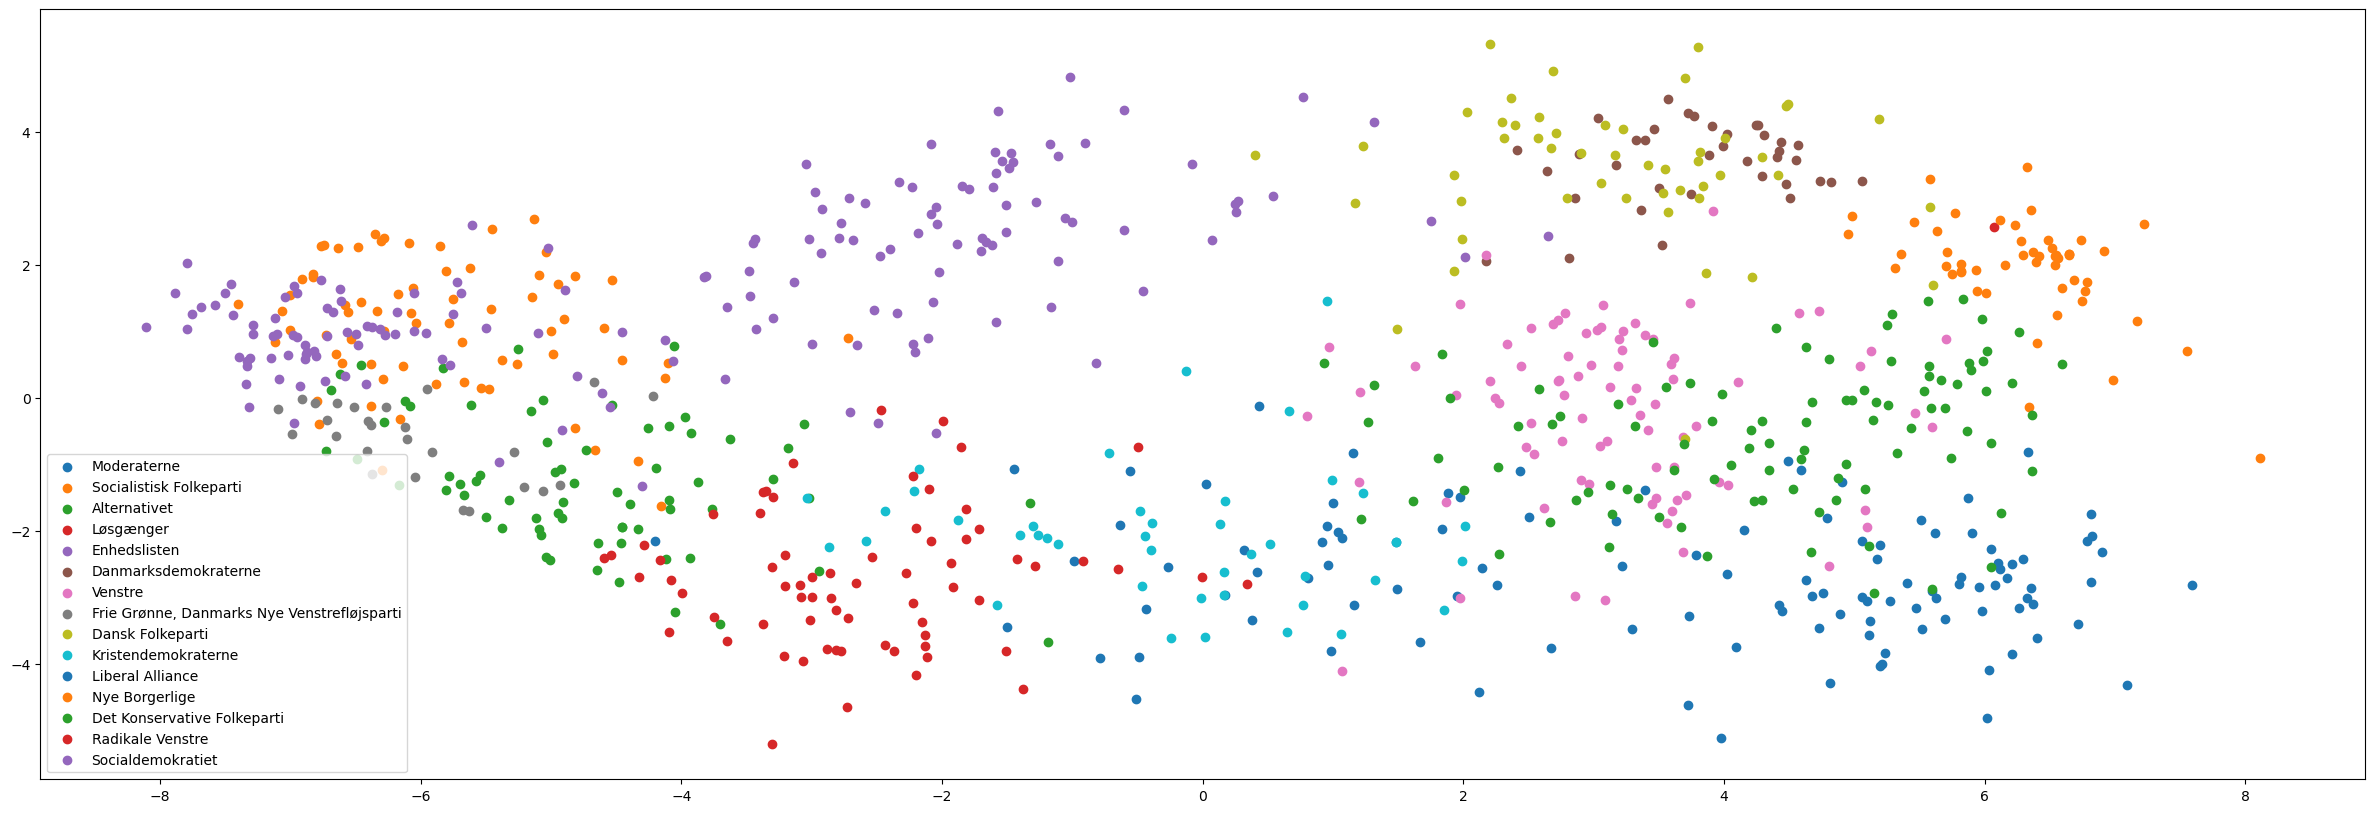

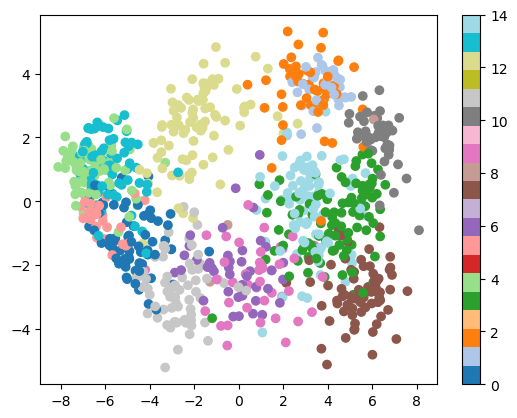

In [84]:
X_pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
X_pca = pd.DataFrame(X_pca, index=X.index, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(30,10))

for parti in y_original.unique():
    ax.scatter(X_pca.loc[y_original == parti, 'PC1'], X_pca.loc[y_original == parti, 'PC2'], label=parti)
    
    
ax.legend()
plt.show()

plt.scatter(X_pca['PC1'], X_pca['PC2'], c=y, cmap='tab20')
plt.colorbar()
plt.show()